In [44]:
!pip install vizdoom

In [45]:
# !cd github & git clone https://github.com/Farama-Foundation/ViZDoom

In [46]:
# Import vizdoom for game env
from vizdoom import *
# Import random for action sampling
import random
# Import time for sleeping
import time
# Import numpy for identity matrix
import numpy as np

In [47]:
# Setup game
game = DoomGame()
game.load_config('github/ViZDoom/scenarios/basic.cfg')
game.init()

In [48]:
# This is the set of actions we can take in the environment
actions = np.identity(3, dtype=np.uint8)

In [49]:
state = game.get_state()

In [50]:
state.game_variables

array([50.])

In [51]:
# Loop through episodes
episodes = 10
for episode in range(episodes):
    # Create a new episode or game
    game.new_episode()
    # Check the game isn't done
    while not game.is_episode_finished():
        # Get the game state
        state = game.get_state()
        # Get the game image
        img = state.screen_buffer
        # Get the game variables - ammo
        info = state.game_variables
        # Take an action
        reward = game.make_action(random.choice(actions), 4)
        # Print reward
        print('reward: ', reward)
        time.sleep(0.02)
    print('Result: ', game.get_total_reward())
    time.sleep(2)

reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  99.0
Result:  87.0
reward:  -4.0
reward:  -9.0
reward:  -4.0
reward:  -4.0
reward:  -9.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -9.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -9.0
reward:  -4.0
reward:  -4.0
reward:  -9.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -9.0
reward:  -4.0
reward:  -4.0
reward:  -9.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -9.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -9.0
reward:  -4.0
reward:  -4.0
reward:  -9.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -9.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -9.0
reward:  -4.0
reward:  -4.0
reward:  -9.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward:  -4.0
reward

In [52]:
game.close()

## 2. Converting it to a Gym Environment

In [53]:
# !pip install gym

In [54]:
# !pip install opencv-python

In [55]:
# Import environment base class from OpenAI Gym
from gym import Env
# Import gym spaces
from gym.spaces import Discrete, Box
# Import opencv
import cv2

In [56]:
# Create Vizdoom OpenAI Gym Environment
class VizDoomGym(Env):
    # Function that is called when we start the env
    def __init__(self, render=False):
        # Inherit from Env
        super().__init__()
        # Setup the game
        self.game = DoomGame()
        self.game.load_config('github/ViZDoom/scenarios/basic.cfg')

        # Render frame logic
        if render == False:
            self.game.set_window_visible(False)
        else:
            self.game.set_window_visible(True)

        # Start the game
        self.game.init()

        # Create the action space and observation space
        self.observation_space = Box(low=0, high=255, shape=(100, 160, 1), dtype=np.uint8)
        self.action_space = Discrete(3)
    
    # This is how we take a step in the environment
    def step(self, action):
        # Specify action and take step
        actions = np.identity(3)
        reward = self.game.make_action(actions[action], 4) # 4 here is the frameskip parameter which makes the game run faster

        # Get all the other stuff we need to return
        if self.game.get_state():
            state = self.game.get_state().screen_buffer
            state = self.grayscale(state)
            ammo = self.game.get_state().game_variables[0]
            info = ammo
        else:
            state = np.zeros(self.observation_space.shape)
            info = 0

        info = {'info': info}
        done = self.game.is_episode_finished()

        return state, reward, done, info
        
    # Define how to render the game or environment
    def render():
        pass

    # What happens when we start a new game
    def reset(self):
        self.game.new_episode()
        state = self.game.get_state().screen_buffer
        return self.grayscale(state)

    # Grayscale the game frame and resize it 
    def grayscale(self, observation):
        gray = cv2.cvtColor(np.moveaxis(observation, 0, -1), cv2.COLOR_BGR2GRAY)
        resize = cv2.resize(gray, (160,100), interpolation=cv2.INTER_CUBIC)
        state = np.reshape(resize, (100,160,1))
        return state

    # Call to close down the game
    def close(self):
        self.game.close()

In [57]:
env = VizDoomGym(render=True)

In [58]:
state = env.reset()

In [59]:
# env.step(2)

In [60]:
env.close()

In [61]:
# Import Environment checker
from stable_baselines3.common import env_checker

In [62]:
# env_checker.check_env(env)

## 3. View State

In [63]:
from matplotlib import pyplot as plt

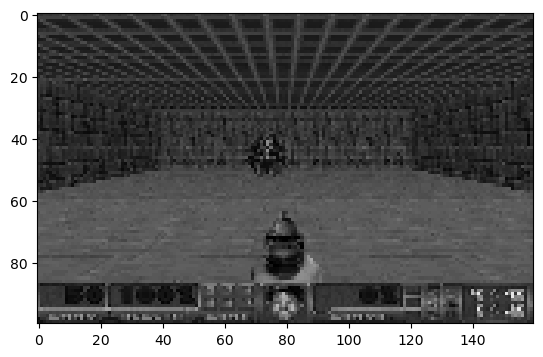

In [64]:
plt.imshow(cv2.cvtColor(state, cv2.COLOR_BGR2RGB))

## 4. Setup Callback

In [65]:
# !pip install stable-baselines3[extra]

In [66]:
# !pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [67]:
# Import os for file nav
import os 
# Import callback class from sb3
from stable_baselines3.common.callbacks import BaseCallback

In [68]:
class TrainAndLoggingCallback(BaseCallback):
    def __init__(self, check_freq, save_path, verbose=1):
        super(TrainAndLoggingCallback, self).__init__(verbose)
        self.check_freq = check_freq
        self.save_path = save_path

    def _init_callback(self):
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self):
        if self.n_calls % self.check_freq == 0:
            model_path = os.path.join(self.save_path, 'best_model_{}'.format(self.n_calls))
            self.model.save(model_path)

        return True

In [69]:
CHECKPOINT_DIR = './train_a2c/train_basic'
LOG_DIR = './logs_a2c/log_basic'

In [70]:
callback = TrainAndLoggingCallback(check_freq=10000, save_path=CHECKPOINT_DIR)

## 5. Train Gym

In [71]:
# Import ppo for training 
from stable_baselines3 import A2C

In [72]:
# Non rendered environment
env = VizDoomGym()

In [73]:
# model = PPO('CnnPolicy', env, tensorboard_log=LOG_DIR, verbose=1, learning_rate=0.0001, n_steps=2048)
model = A2C(
    'CnnPolicy',  # For visual input
    env, 
    verbose=1, 
    learning_rate=0.0002,  # Slightly lower learning rate for fine-grained learning
    n_steps=128,  # Shorter steps for better temporal alignment
    gamma=0.99,  # High discount factor for long-term rewards
    gae_lambda=0.95,  # GAE for bias-variance balance
    ent_coef=0.02,  # Higher entropy for encouraging exploration
    vf_coef=0.3,  # Slightly reduced to balance policy and value loss
    max_grad_norm=0.5,  # Gradient clipping for stability
    tensorboard_log=LOG_DIR  # Log training metrics
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.


In [74]:
# model.learn(total_timesteps=100000, callback=callback)
model.learn(total_timesteps=100000, callback=callback)  # Train for 100,000 timesteps initially

Logging to ./logs_a2c/log_basic\A2C_1
-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 75        |
|    ep_rew_mean        | -300      |
| time/                 |           |
|    fps                | 28        |
|    iterations         | 100       |
|    time_elapsed       | 447       |
|    total_timesteps    | 12800     |
| train/                |           |
|    entropy_loss       | -3.78e-05 |
|    explained_variance | 0.142     |
|    learning_rate      | 0.0002    |
|    n_updates          | 99        |
|    policy_loss        | 1.83e-05  |
|    value_loss         | 1.99e+03  |
-------------------------------------
-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 75        |
|    ep_rew_mean        | -300      |
| time/                 |           |
|    fps                | 28        |
|    iterations         | 200       |
|    time_elapsed       | 888       |
|    total_t

## 6. Test the Model

In [82]:
# Import eval policy to test agent
from stable_baselines3.common.evaluation import evaluate_policy

In [83]:
# Reload model from disk
model = A2C.load('./train_a2c/train_basic/best_model_80000.zip')

In [84]:
# Create rendered environment
env = VizDoomGym(render=True)

In [85]:
# Evaluate mean reward for 10 games
mean_reward, _ = evaluate_policy(model, env, n_eval_episodes=25)

In [86]:
mean_reward

-300.0

In [87]:
for episode in range(5):
    obs = env.reset()
    done = False
    total_reward = 0
    while not done:
        action, _ = model.predict(obs)
        obs, reward, done, info = env.step(action)
        time.sleep(0.20)
        total_reward += reward

    print('Total Reward for episode {} is {}'.format(episode, total_reward))
    time.sleep(2)

Total Reward for episode 0 is -300.0
Total Reward for episode 1 is -300.0
Total Reward for episode 2 is -300.0
Total Reward for episode 3 is -300.0
Total Reward for episode 4 is -300.0


In [88]:
mean_reward, _ = evaluate_policy(model, env, n_eval_episodes=100)
print(f'Mean reward over 100 episodes: {mean_reward}')

Mean reward over 100 episodes: -300.0


In [89]:
episode_lengths = []
success_count = 0
rewards = []

# Define a success threshold (e.g., 10 as an example; adjust based on your environment)
success_threshold = 10

for episode in range(100):
    obs = env.reset()
    done = False
    total_reward = 0
    steps = 0

    while not done:
        action, _ = model.predict(obs)
        obs, reward, done, info = env.step(action)
        total_reward += reward
        steps += 1

    episode_lengths.append(steps)
    rewards.append(total_reward)
    
    # Check if the episode is successful
    if total_reward > success_threshold:
        success_count += 1

avg_episode_length = np.mean(episode_lengths)
success_rate = success_count / 100
reward_variance = np.var(rewards)

print(f'Average Episode Length: {avg_episode_length}')
print(f'Success Rate: {success_rate}')
print(f'Reward Variance (Stability): {reward_variance}')

Average Episode Length: 75.0
Success Rate: 0.0
Reward Variance (Stability): 0.0


### Import Necessary Libraries for Visualization

In [90]:
import matplotlib.pyplot as plt
import numpy as np

### Visualizations!

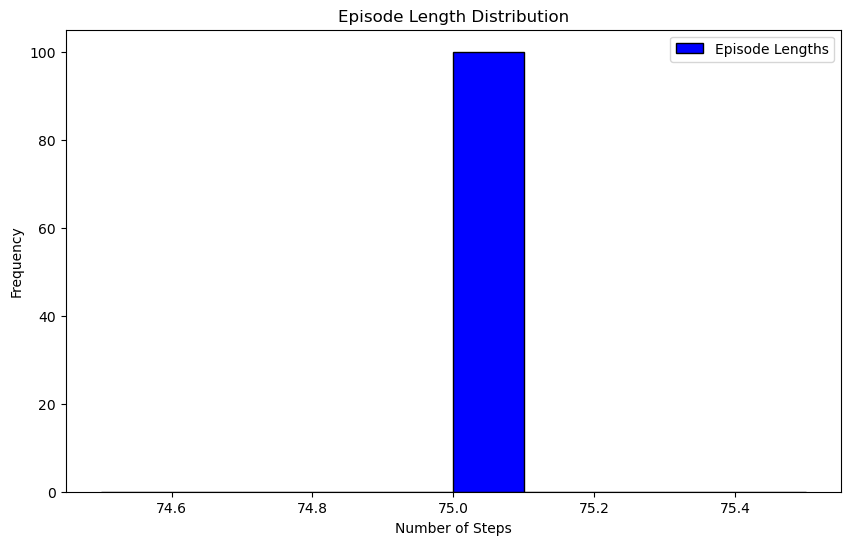

In [91]:
# Visualize Episode Length Distribution
plt.figure(figsize=(10, 6))
plt.hist(episode_lengths, bins=10, color='blue', edgecolor='black', label='Episode Lengths')
plt.title('Episode Length Distribution')
plt.xlabel('Number of Steps')
plt.ylabel('Frequency')
plt.legend(loc='upper right')  # Add legend
plt.show()

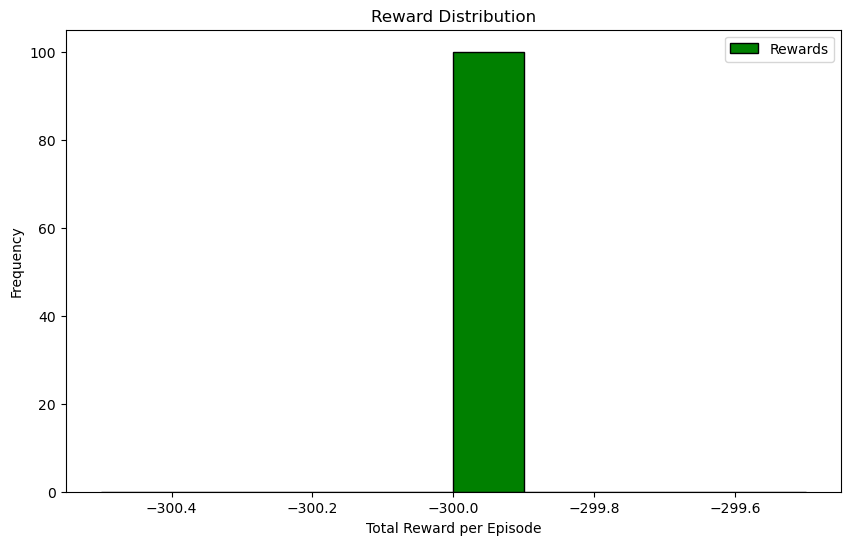

In [92]:
# Visualize Reward Distribution
plt.figure(figsize=(10, 6))
plt.hist(rewards, bins=10, color='green', edgecolor='black', label='Rewards')
plt.title('Reward Distribution')
plt.xlabel('Total Reward per Episode')
plt.ylabel('Frequency')
plt.legend(loc='upper right')  # Add legend
plt.show()

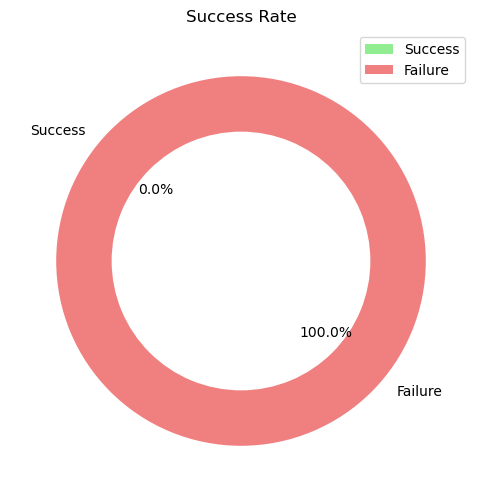

In [93]:
# Visualize Success Rate (Doughnut Chart)
plt.figure(figsize=(6, 6))
labels = ['Success', 'Failure']
sizes = [success_rate * 100, (1 - success_rate) * 100]
colors = ['lightgreen', 'lightcoral']

# Create a doughnut chart
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, wedgeprops=dict(width=0.3))

# Add a legend
plt.legend(labels, loc='best')

plt.title('Success Rate')
plt.show()

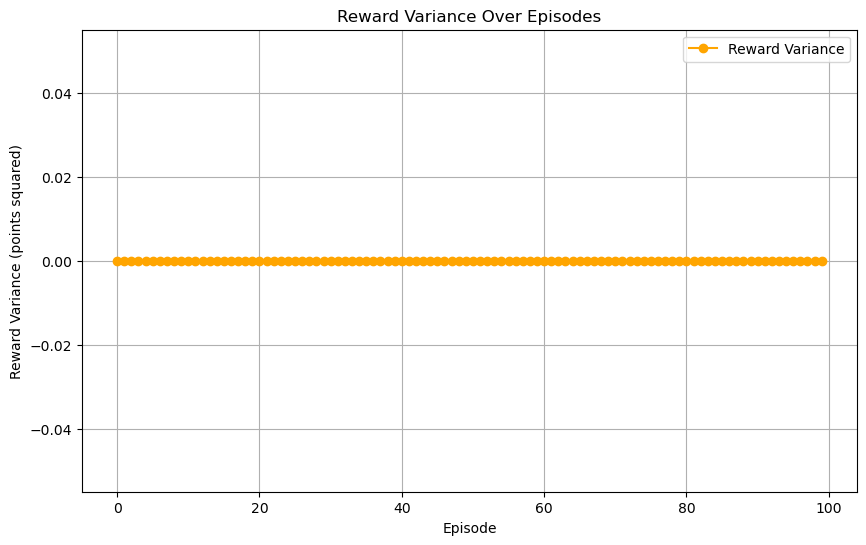

In [94]:
# Visualize Reward Variance Over Time (Line Chart)
reward_variances = []

for episode in range(100):
    obs = env.reset()
    done = False
    total_reward = 0

    while not done:
        action, _ = model.predict(obs)
        obs, reward, done, info = env.step(action)
        total_reward += reward

    rewards.append(total_reward)
    if len(rewards) > 1:
        variance = np.var(rewards)
        reward_variances.append(variance)

# Create a line chart for reward variance
plt.figure(figsize=(10, 6))
plt.plot(reward_variances, color='orange', marker='o', label='Reward Variance')
plt.title('Reward Variance Over Episodes')
plt.xlabel('Episode')
plt.ylabel('Reward Variance (points squared)')
plt.grid(True)
plt.legend(loc='upper right')  # Add legend
plt.show()